# Marketing Channel Performance & Attribution 

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", palette="rocket")
pd.set_option('display.max_columns', None)

# Загрузка данных

In [18]:
orders = pd.read_csv("orders_subset.csv")
intervals = pd.read_csv("intervals_subset.csv")

intervals.csv — задекларированная ёмкость слотов

- slot_id int Идентификатор слота (хеш). Ключ связи с orders.
- interval_start_date date Дата доставки слота. Ключ связи с orders.
- level_2 str Расположение полигона доставки. Уровень иерархии 2.
- level_1 str Расположение полигона доставки. Уровень иерархии 1.
- src_zone_id int Идентификатор зоны доставки.
- service_level_code str Уровень сервиса (plus15, economy, exact60, same_day и т.д.).
- interval_cutoff_dttm datetime Время отсечки приёма заказов в слот (cutoff).
- interval_start_dttm datetime Начало интервала доставки.
- interval_end_dttm datetime Конец интервала доставки.
- created_at datetime Время первого появления интервала в истории (минимальное).
- available_capacity_first float Первый зафиксированный размер ёмкости слота. NaN — если история ёмкости отсутствует.
- available_capacity_last float Последний зафиксированный размер ёмкости слота. NaN — если история отсутствует.
- was_expanded int 1, если ёмкость расширялась (last > first), иначе 0.
- capacity_delta float Изменение ёмкости: last − first.


In [19]:
intervals.dtypes

slot_id                       int64
interval_start_date             str
level_2                         str
level_1                         str
src_zone_id                   int64
service_level_code              str
interval_cutoff_dttm            str
interval_start_dttm             str
interval_end_dttm               str
created_at                      str
available_capacity_first    float64
available_capacity_last     float64
was_expanded                  int64
capacity_delta              float64
dtype: object

In [20]:
datetime_cols = ["interval_start_date", "interval_cutoff_dttm", "interval_start_dttm", "interval_end_dttm", "created_at"]

for cols in datetime_cols:
    intervals[cols] = pd.to_datetime(intervals[cols] )

intervals.dtypes

slot_id                              int64
interval_start_date         datetime64[us]
level_2                                str
level_1                                str
src_zone_id                          int64
service_level_code                     str
interval_cutoff_dttm        datetime64[us]
interval_start_dttm         datetime64[us]
interval_end_dttm           datetime64[us]
created_at                  datetime64[us]
available_capacity_first           float64
available_capacity_last            float64
was_expanded                         int64
capacity_delta                     float64
dtype: object

In [21]:
intervals.sample(3)

,slot_id,interval_start_date,level_2,level_1,src_zone_id,service_level_code,interval_cutoff_dttm,interval_start_dttm,interval_end_dttm,created_at,available_capacity_first,available_capacity_last,was_expanded,capacity_delta
132136,2216400570,2024-10-11,Moscow,LMD Moscow South,1261251,plus,2024-10-10 23:59:00,2024-10-11 20:00:00,2024-10-12 00:00:00,2024-09-11 02:36:03,15.0,21.0,1,6.0
88409,1487336525,2024-10-25,Moscow,LMD Moscow South,1467567,plus15,2024-10-24 23:59:00,2024-10-25 21:30:00,2024-10-25 21:45:00,2024-09-25 02:24:01,2.0,2.0,0,0.0
192263,3225427935,2024-10-17,Moscow,LMD Moscow South,1569908,plus15,2024-10-16 23:59:00,2024-10-17 13:15:00,2024-10-17 13:30:00,2024-09-17 02:15:03,2.0,1.0,0,-1.0


In [22]:
datetime_cols = ["interval_start_date", "interval_start_dttm", "interval_end_dttm", "order_hour"]

for cols in datetime_cols:
    orders[cols] = pd.to_datetime(orders[cols] )

orders.dtypes

slot_id                              int64
interval_start_date         datetime64[us]
src_zone_id                          int64
service_level_code                     str
interval_start_dttm         datetime64[us]
interval_end_dttm           datetime64[us]
order_hour                  datetime64[us]
consumed_capacity_hourly             int64
consumed_capacity_cum                int64
dtype: object

In [23]:
"""
проверю заявленную гранулярность в данных
intervals — одна строка на слот (slot_id + дата). Уникальный ключ.
"""
intervals.groupby(["slot_id", 'interval_start_date']).agg(cnt=("slot_id", "count")).sort_values("cnt", ascending=False).sort_values("slot_id")
# валидно

,,cnt
slot_id,interval_start_date,
20694,2024-09-22,1
43529,2024-09-07,1
44642,2024-10-17,1
60229,2024-10-22,1
88805,2024-09-30,1
...,...,...
4294852545,2024-09-05,1
4294906374,2024-09-27,1
4294925474,2024-09-16,1


In [24]:
"""
orders — одна строка на (слот + час оформления заказа). На один слот может приходиться несколько строк.
"""
orders.groupby(["slot_id", 'order_hour']).agg(cnt=("slot_id", "count")).sort_values("cnt", ascending=False)
# валидно

cnt
slot_id    order_hour              
189487     2024-10-12 20:00:00    1
2867528941 2024-10-04 21:00:00    1
2867110379 2024-10-23 19:00:00    1
           2024-10-23 20:00:00    1
           2024-10-23 21:00:00    1
...                             ...
1428946092 2024-08-28 17:00:00    1
           2024-08-31 10:00:00    1
           2024-08-31 11:00:00    1
           2024-08-31 18:00:00    1
4294925474 2024-09-15 23:00:00    1

[249399 rows x 1 columns]

In [25]:
print(orders.shape)
print(intervals.shape)

(249399, 9)
(255862, 14)


In [26]:
intervals["capacity_delta"].max()

np.float64(50.0)

# 0. Проанализировать данные вообще

In [27]:
intervals.groupby(["slot_id", ]).agg(capacity=("capacity_delta", "count")).sort_values("capacity", ascending=False)

,capacity
slot_id,
3881547230,2
3503731572,2
659197114,2
3097118861,2
2863584191,1
...,...
1435084164,1
1435084326,1
1435099479,1


In [28]:
intervals[intervals["slot_id"]==3881547230]

,slot_id,interval_start_date,level_2,level_1,src_zone_id,service_level_code,interval_cutoff_dttm,interval_start_dttm,interval_end_dttm,created_at,available_capacity_first,available_capacity_last,was_expanded,capacity_delta
231248,3881547230,2024-10-19,Moscow,LMD Moscow South,1512726,exact60,2024-10-18 23:59:00,2024-10-19 23:00:00,2024-10-20 00:00:00,2024-09-19 02:15:03,2.0,2.0,0,0.0
231249,3881547230,2024-10-22,Moscow,LMD Moscow South,1512727,plus15,2024-10-21 23:59:00,2024-10-22 14:30:00,2024-10-22 14:45:00,2024-09-22 02:15:03,2.0,1.0,0,-1.0


        емкость нескольких слотов изменялась, они открывались повторно

In [29]:
# объединю обе таблицы, проверю пересечение слотов и заказов
## сначала для всех ли слотов есть информация о заказах
all_slots_for_orders = pd.merge(intervals, orders, on=["slot_id", "interval_start_date"], how="left", indicator=True)
all_slots_for_orders["_merge"].value_counts()

_merge
both          249361
left_only     203880
right_only         0
Name: count, dtype: int64

    203_880 слотов не нашли совпадений в orders - то есть слоты еще не заполненные заказами.

In [30]:
# но сначала поизучаю все ли заказы разложены по слотам, объединю данные по правой таблице orders
all_orders_to_slots = pd.merge(
    intervals,
    orders,
    on=["slot_id", "interval_start_date"],
    how="right",
    indicator=True
)
all_orders_to_slots["_merge"].value_counts()

_merge
both          249361
right_only        38
left_only          0
Name: count, dtype: int64

        нашлось 38 заказов, не определенных в слоты таблицы intervals по двойному ключу, посмотрю на них.

In [31]:
orders_no_slots = all_orders_to_slots[all_orders_to_slots["_merge"]=="right_only"][[
    'slot_id','interval_start_date','src_zone_id_y','service_level_code_y','interval_start_dttm_y','interval_end_dttm_y','order_hour','consumed_capacity_hourly', 'consumed_capacity_cum'
    ]]
slots_list_orders_no_slots = orders_no_slots['slot_id'].unique()
slots_list_orders_no_slots

array([2998979378, 3870628422, 4283844139,   85391172, 2225310683,
       1785386412, 1750036747])

In [32]:
intervals[intervals["slot_id"].isin(slots_list_orders_no_slots)]

,slot_id,interval_start_date,level_2,level_1,src_zone_id,service_level_code,interval_cutoff_dttm,interval_start_dttm,interval_end_dttm,created_at,available_capacity_first,available_capacity_last,was_expanded,capacity_delta
5014,85391172,2024-09-26,Moscow,LMD Moscow South,1467567,exact60,2024-09-25 23:59:00,2024-09-26 12:00:00,2024-09-26 13:00:00,2024-08-27 02:15:03,2.0,2.0,0,0.0
104096,1750036747,2024-10-03,Moscow,LMD Moscow South,1220838,plus15,2024-10-02 23:59:00,2024-10-03 14:15:00,2024-10-03 14:30:00,2024-09-19 17:30:05,1.0,1.0,0,0.0
106216,1785386412,2024-09-26,Moscow,LMD Moscow South,1583442,same_day,2024-09-26 12:00:00,2024-09-26 18:00:00,2024-09-26 20:00:00,2024-08-27 03:15:24,12.0,12.0,0,0.0
132662,2225310683,2024-09-06,Moscow,LMD Moscow South,1134533,exact60,2024-09-05 23:59:00,2024-09-06 12:00:00,2024-09-06 13:00:00,2024-08-07 02:15:03,4.0,4.0,0,0.0
178700,2998979378,2024-09-24,Moscow,LMD Moscow South,1134534,plus15,2024-09-23 23:59:00,2024-09-24 13:00:00,2024-09-24 13:15:00,2024-08-25 02:15:03,2.0,2.0,0,0.0
230608,3870628422,2024-09-22,Moscow,LMD Moscow South,1253463,plus15,2024-09-21 23:59:00,2024-09-22 09:15:00,2024-09-22 09:30:00,2024-08-23 02:15:03,1.0,1.0,0,0.0
255176,4283844139,2024-10-17,Moscow,LMD Moscow South,1101682,economy,2024-10-16 23:59:00,2024-10-17 12:00:00,2024-10-17 16:00:00,2024-09-24 10:27:10,15.0,15.0,0,0.0


In [33]:
orders_no_slots[orders_no_slots["slot_id"]==85391172]

,slot_id,interval_start_date,src_zone_id_y,service_level_code_y,interval_start_dttm_y,interval_end_dttm_y,order_hour,consumed_capacity_hourly,consumed_capacity_cum
71890,85391172,2024-09-01,1134535,economy,2024-09-01 08:00:00,2024-09-01 12:00:00,2024-08-29 00:00:00,1,1
71891,85391172,2024-09-01,1134535,economy,2024-09-01 08:00:00,2024-09-01 12:00:00,2024-08-31 14:00:00,1,2
71892,85391172,2024-09-01,1134535,economy,2024-09-01 08:00:00,2024-09-01 12:00:00,2024-08-31 18:00:00,1,3
71893,85391172,2024-09-01,1134535,economy,2024-09-01 08:00:00,2024-09-01 12:00:00,2024-08-31 22:00:00,1,4


In [34]:
orders_no_slots[orders_no_slots["slot_id"]==1785386412]

,slot_id,interval_start_date,src_zone_id_y,service_level_code_y,interval_start_dttm_y,interval_end_dttm_y,order_hour,consumed_capacity_hourly,consumed_capacity_cum
76404,1785386412,2024-10-03,1184352,plus,2024-10-03 14:00:00,2024-10-03 18:00:00,2024-09-21 19:00:00,1,1
76405,1785386412,2024-10-03,1184352,plus,2024-10-03 14:00:00,2024-10-03 18:00:00,2024-09-24 16:00:00,1,2
76406,1785386412,2024-10-03,1184352,plus,2024-10-03 14:00:00,2024-10-03 18:00:00,2024-09-24 18:00:00,1,3
76407,1785386412,2024-10-03,1184352,plus,2024-10-03 14:00:00,2024-10-03 18:00:00,2024-09-29 22:00:00,1,4
76408,1785386412,2024-10-03,1184352,plus,2024-10-03 14:00:00,2024-10-03 18:00:00,2024-09-30 04:00:00,1,5
76409,1785386412,2024-10-03,1184352,plus,2024-10-03 14:00:00,2024-10-03 18:00:00,2024-09-30 07:00:00,1,6
76410,1785386412,2024-10-03,1184352,plus,2024-10-03 14:00:00,2024-10-03 18:00:00,2024-09-30 12:00:00,1,7
76411,1785386412,2024-10-03,1184352,plus,2024-10-03 14:00:00,2024-10-03 18:00:00,2024-09-30 13:00:00,1,8
76412,1785386412,2024-10-03,1184352,plus,2024-10-03 14:00:00,2024-10-03 18:00:00,2024-09-30 16:00:00,1,9
76413,1785386412,2024-10-03,1184352,plus,2024-10-03 14:00:00,2024-10-03 18:00:00,2024-09-30 18:00:00,2,11


    38 cтрок из таблицы orders, не нашедшие ключа ["slot_id", "interval_start_date"] в intervals, при этом их slots_id находятся в intervals.
    например, слот 85391172 в intervals открыт более поздней датой 2024-09-26, чем в потеряшках interval_start_date==2024-09-01, 
    а слот 1785386412 в intervals открыт раньше - 2024-09-26 (закрыт 2024-09-26 20:00:00), а в потеряшках открыт 2024-10-03.

    В общем, есть некоторая коллизия в данных,  возможно ручные корректировки слотов, отмены/переносы заказов, проводки задним числом.
    Думаю, имело бы смысл поизучать их подробнее (сохранить их отдельно и передать/изучить), а сейчас я бы расссматривала их как data quality issues и пока пренебрегла бы ими в дальнейшем анализе.

In [35]:
orders_no_slots.to_csv("orders_no_slots.csv")

# 1. Проанализировать данные об истории наполнения слотов доставки

        Изучу выборку со всеми слотами all_slots_for_orders

In [36]:
# сначала немного ее подчищу
# удостоверюсь, одноименные поля в обоих таблицах полностью дублируются
all_slots_for_orders[(all_slots_for_orders["interval_start_dttm_x"]!=all_slots_for_orders["interval_start_dttm_y"])&(all_slots_for_orders["_merge"]=="both")]
all_slots_for_orders[(all_slots_for_orders["interval_end_dttm_x"]!=all_slots_for_orders["interval_end_dttm_y"])&(all_slots_for_orders["_merge"]=="both")]
all_slots_for_orders[(all_slots_for_orders["service_level_code_x"]!=all_slots_for_orders["service_level_code_y"])&(all_slots_for_orders["_merge"]=="both")]


,slot_id,interval_start_date,level_2,level_1,src_zone_id_x,service_level_code_x,interval_cutoff_dttm,interval_start_dttm_x,interval_end_dttm_x,created_at,available_capacity_first,available_capacity_last,was_expanded,capacity_delta,src_zone_id_y,service_level_code_y,interval_start_dttm_y,interval_end_dttm_y,order_hour,consumed_capacity_hourly,consumed_capacity_cum,_merge


In [37]:
# удалю дубликаты и переименую
all_slots_for_orders.drop(columns=['interval_start_dttm_y', 'interval_end_dttm_y','src_zone_id_y', 'service_level_code_y'], axis=0, inplace=True)
all_slots_for_orders.rename(columns={'src_zone_id_x':'src_zone_id','service_level_code_x':'service_level_code','interval_start_dttm_x':'interval_start_dttm','interval_end_dttm_x':'interval_end_dttm' })

,slot_id,interval_start_date,level_2,level_1,src_zone_id,service_level_code,interval_cutoff_dttm,interval_start_dttm,interval_end_dttm,created_at,available_capacity_first,available_capacity_last,was_expanded,capacity_delta,order_hour,consumed_capacity_hourly,consumed_capacity_cum,_merge
0,20694,2024-09-22,Moscow,LMD Moscow South,1220839,exact60,2024-09-21 23:59:00,2024-09-22 18:00:00,2024-09-22 19:00:00,2024-08-23 02:15:03,2.0,2.0,0,0.0,NaT,NaN,NaN,left_only
1,43529,2024-09-07,Moscow,LMD Moscow South,1354357,same_day60,2024-09-07 15:30:00,2024-09-07 23:00:00,2024-09-07 23:59:00,2024-08-08 03:09:12,5.0,5.0,0,0.0,NaT,NaN,NaN,left_only
2,44642,2024-10-17,Moscow,LMD Moscow South,1263362,plus15,2024-10-16 23:59:00,2024-10-17 19:30:00,2024-10-17 19:45:00,2024-09-17 02:15:03,2.0,2.0,0,0.0,NaT,NaN,NaN,left_only
3,60229,2024-10-22,Moscow,LMD Moscow South,1512698,plus15,2024-10-21 23:59:00,2024-10-22 19:00:00,2024-10-22 19:15:00,2024-09-22 02:15:03,2.0,1.0,0,-1.0,NaT,NaN,NaN,left_only
4,88805,2024-09-30,Moscow,LMD Moscow South,1261250,plus15,2024-09-29 23:59:00,2024-09-30 08:15:00,2024-09-30 08:30:00,2024-08-31 02:38:23,1.0,1.0,0,0.0,NaT,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453236,4294925474,2024-09-16,Moscow,LMD Moscow South,1169002,economy,2024-09-15 23:59:00,2024-09-16 17:00:00,2024-09-16 21:00:00,2024-08-17 02:15:03,4.0,3.0,0,-1.0,2024-09-15 13:00:00,1.0,1.0,both
453237,4294925474,2024-09-16,Moscow,LMD Moscow South,1169002,economy,2024-09-15 23:59:00,2024-09-16 17:00:00,2024-09-16 21:00:00,2024-08-17 02:15:03,4.0,3.0,0,-1.0,2024-09-15 19:00:00,1.0,2.0,both
453238,4294925474,2024-09-16,Moscow,LMD Moscow South,1169002,economy,2024-09-15 23:59:00,2024-09-16 17:00:00,2024-09-16 21:00:00,2024-08-17 02:15:03,4.0,3.0,0,-1.0,2024-09-15 23:00:00,1.0,3.0,both
453239,4294929758,2024-09-29,Moscow,LMD Moscow South,1261250,plus15,2024-09-28 23:59:00,2024-09-29 11:00:00,2024-09-29 11:15:00,2024-08-30 02:39:40,2.0,1.0,0,-1.0,NaT,NaN,NaN,left_only


In [38]:
"""
агрегирую по ключу слот-дата старта и собираю параметры слота
"""
slot_level = (
    all_slots_for_orders.sort_values(by=["slot_id","interval_start_date", "consumed_capacity_cum"]).groupby(['slot_id','interval_start_date'],as_index=False).agg(
        src_zone_id=("src_zone_id_x", "first"),
        service_level_code=("service_level_code_x", "first"),
        level_1=("level_1", "first"),
        level_2=("level_2", "first"),

        interval_cutoff_dttm=("interval_cutoff_dttm", "first"),
        interval_start_dttm=("interval_start_dttm_x", "first"),
        interval_end_dttm=("interval_end_dttm_x", "first"),

        available_capacity_first=("available_capacity_first", "first"),
        available_capacity_last=("available_capacity_last", "first"),
        capacity_delta=("capacity_delta", "first"),
        was_expanded=("was_expanded", "first"),

        first_order_hour=("order_hour", "min"),
        last_order_hour=("order_hour", "max"),
        consumed_capacity_hourly_sum=("consumed_capacity_hourly", "sum"), # для проверки, совпадает ли накопленная сумма с посчитанной тут
        consumed_capacity=("consumed_capacity_cum", "max")
    )
)


In [39]:
slot_level[~slot_level["first_order_hour"].isna()]

,slot_id,interval_start_date,src_zone_id,service_level_code,level_1,level_2,interval_cutoff_dttm,interval_start_dttm,interval_end_dttm,available_capacity_first,available_capacity_last,capacity_delta,was_expanded,first_order_hour,last_order_hour,consumed_capacity_hourly_sum,consumed_capacity
14,189487,2024-10-13,1513143,exact60,LMD Moscow South,Moscow,2024-10-12 23:59:00,2024-10-13 19:00:00,2024-10-13 20:00:00,3.0,1.0,-2.0,0,2024-10-12 20:00:00,2024-10-12 20:00:00,1.0,1.0
36,604881,2024-10-10,35,plus,LMD Moscow South,Moscow,2024-10-09 23:59:00,2024-10-10 09:00:00,2024-10-10 13:00:00,40.0,35.0,-5.0,0,2024-10-03 06:00:00,2024-10-09 21:00:00,38.0,38.0
39,661778,2024-09-03,1261252,economy,LMD Moscow South,Moscow,2024-09-02 23:59:00,2024-09-03 12:00:00,2024-09-03 16:00:00,20.0,20.0,0.0,0,2024-08-27 10:00:00,2024-09-03 02:00:00,8.0,8.0
45,742364,2024-10-15,1134534,plus,LMD Moscow South,Moscow,2024-10-14 23:59:00,2024-10-15 16:00:00,2024-10-15 20:00:00,29.0,29.0,0.0,0,2024-10-08 03:00:00,2024-10-14 04:00:00,26.0,26.0
58,1010533,2024-10-15,1513142,economy,LMD Moscow South,Moscow,2024-10-14 23:59:00,2024-10-15 16:00:00,2024-10-15 20:00:00,11.0,5.0,-6.0,0,2024-10-09 14:00:00,2024-10-15 02:00:00,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255839,4294538455,2024-10-20,1101682,exact60,LMD Moscow South,Moscow,2024-10-19 23:59:00,2024-10-20 20:00:00,2024-10-20 21:00:00,4.0,1.0,-3.0,0,2024-10-19 01:00:00,2024-10-19 01:00:00,1.0,1.0
255846,4294662154,2024-10-02,1253463,exact60,LMD Moscow South,Moscow,2024-10-01 23:59:00,2024-10-02 13:00:00,2024-10-02 14:00:00,3.0,3.0,0.0,0,2024-10-01 03:00:00,2024-10-02 01:00:00,4.0,4.0
255855,4294838198,2024-09-13,1467568,economy,LMD Moscow South,Moscow,2024-09-12 23:59:00,2024-09-13 08:00:00,2024-09-13 12:00:00,10.0,10.0,0.0,0,2024-09-07 20:00:00,2024-09-12 22:00:00,10.0,10.0
255857,4294852545,2024-09-05,1583449,same_day,LMD Moscow South,Moscow,2024-09-05 12:00:00,2024-09-05 18:00:00,2024-09-05 20:00:00,12.0,12.0,0.0,0,2024-09-05 11:00:00,2024-09-05 13:00:00,3.0,3.0


In [40]:
# заполню нулями поля заполненной емкости заказами
slot_level["consumed_capacity"] = slot_level["consumed_capacity"].fillna(0)
slot_level["consumed_capacity_hourly_sum"] = slot_level["consumed_capacity_hourly_sum"].fillna(0)

In [41]:
# добавлю поле свободной емкости как разницу между заявленной последней и потребленной на заказы
slot_level["free_capacity"] = slot_level["available_capacity_last"] - slot_level["consumed_capacity"]
slot_level[slot_level['first_order_hour'].isna()]

,slot_id,interval_start_date,src_zone_id,service_level_code,level_1,level_2,interval_cutoff_dttm,interval_start_dttm,interval_end_dttm,available_capacity_first,available_capacity_last,capacity_delta,was_expanded,first_order_hour,last_order_hour,consumed_capacity_hourly_sum,consumed_capacity,free_capacity
0,20694,2024-09-22,1220839,exact60,LMD Moscow South,Moscow,2024-09-21 23:59:00,2024-09-22 18:00:00,2024-09-22 19:00:00,2.0,2.0,0.0,0,NaT,NaT,0.0,0.0,2.0
1,43529,2024-09-07,1354357,same_day60,LMD Moscow South,Moscow,2024-09-07 15:30:00,2024-09-07 23:00:00,2024-09-07 23:59:00,5.0,5.0,0.0,0,NaT,NaT,0.0,0.0,5.0
2,44642,2024-10-17,1263362,plus15,LMD Moscow South,Moscow,2024-10-16 23:59:00,2024-10-17 19:30:00,2024-10-17 19:45:00,2.0,2.0,0.0,0,NaT,NaT,0.0,0.0,2.0
3,60229,2024-10-22,1512698,plus15,LMD Moscow South,Moscow,2024-10-21 23:59:00,2024-10-22 19:00:00,2024-10-22 19:15:00,2.0,1.0,-1.0,0,NaT,NaT,0.0,0.0,1.0
4,88805,2024-09-30,1261250,plus15,LMD Moscow South,Moscow,2024-09-29 23:59:00,2024-09-30 08:15:00,2024-09-30 08:30:00,1.0,1.0,0.0,0,NaT,NaT,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255854,4294837150,2024-09-19,1395052,exact60,LMD Moscow South,Moscow,2024-09-18 23:59:00,2024-09-19 15:00:00,2024-09-19 16:00:00,2.0,2.0,0.0,0,NaT,NaT,0.0,0.0,2.0
255856,4294844078,2024-09-20,1514540,plus15,LMD Moscow South,Moscow,2024-09-19 23:59:00,2024-09-20 17:30:00,2024-09-20 17:45:00,2.0,2.0,0.0,0,NaT,NaT,0.0,0.0,2.0
255858,4294906374,2024-09-27,1467567,exact60,LMD Moscow South,Moscow,2024-09-26 23:59:00,2024-09-27 08:00:00,2024-09-27 09:00:00,1.0,1.0,0.0,0,NaT,NaT,0.0,0.0,1.0
255860,4294929758,2024-09-29,1261250,plus15,LMD Moscow South,Moscow,2024-09-28 23:59:00,2024-09-29 11:00:00,2024-09-29 11:15:00,2.0,1.0,-1.0,0,NaT,NaT,0.0,0.0,1.0


In [42]:
"""
теперь соберу датасет по таймлайну для графика, который будет отражать загруженность по дням, то есть сделю агрегацию по дням, собирая все слоты в дне и всю доступную емкость
"""
timeline = (
    slot_level.groupby("interval_start_date", as_index=False).agg(
        slots_cnt=("slot_id", "count"),
        total_capacity=("available_capacity_last", "sum"),
        total_consumed_capacity=("consumed_capacity", "sum"),
        total_free_capacity=("free_capacity","sum")

    )
)

timeline

,interval_start_date,slots_cnt,total_capacity,total_consumed_capacity,total_free_capacity
0,2024-09-01,4148,11569.0,5599.0,5970.0
1,2024-09-02,4248,16505.0,5640.0,10865.0
2,2024-09-03,4106,19714.0,4998.0,14716.0
3,2024-09-04,1313,11724.0,4615.0,7109.0
4,2024-09-05,915,11470.0,4618.0,6852.0
...,...,...,...,...,...
56,2024-10-27,4409,12765.0,5510.0,7255.0
57,2024-10-28,4490,14563.0,5909.0,8654.0
58,2024-10-29,4339,18543.0,4488.0,14055.0
59,2024-10-30,4499,17783.0,5264.0,12519.0


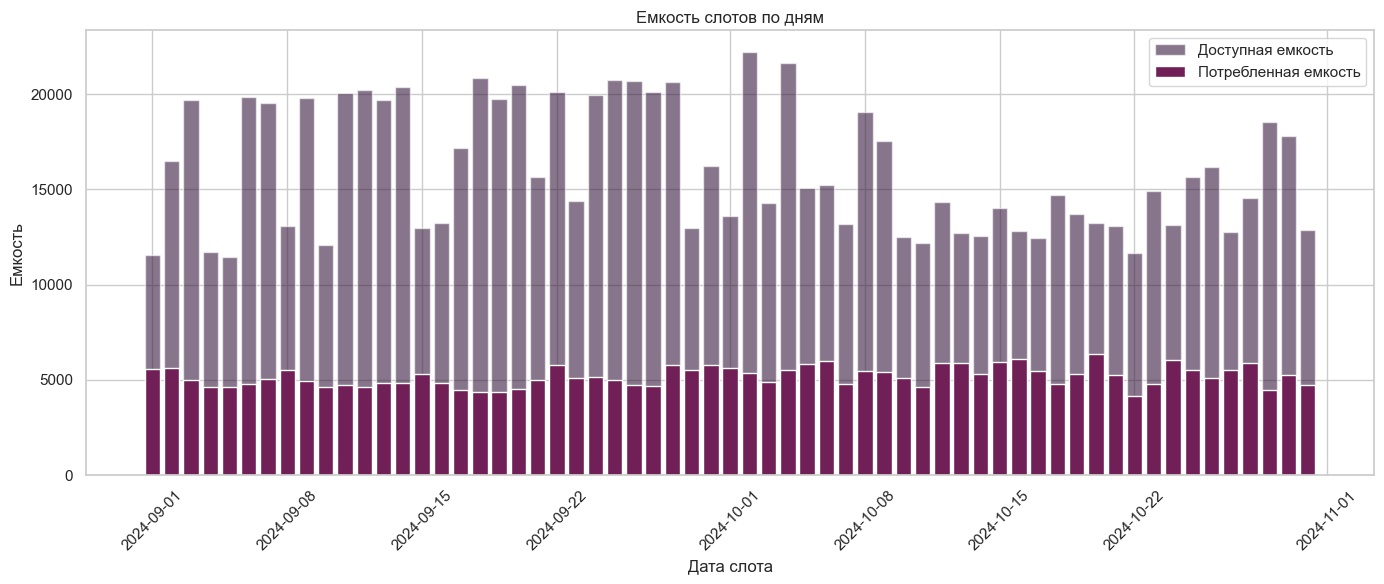

In [43]:
plt.figure(figsize=(14, 6))

plt.bar(
    timeline["interval_start_date"],
    timeline["total_capacity"],
    label="Доступная емкость",
    alpha=0.6
)

plt.bar(
    timeline["interval_start_date"],
    timeline["total_consumed_capacity"],
    label="Потребленная емкость"
)

plt.xticks(rotation=45)
plt.title("Емкость слотов по дням")
plt.xlabel("Дата слота")
plt.ylabel("Емкость")
plt.legend()
plt.tight_layout()
plt.show()

        График показывает довольно большую долю незаполенности слотов.
        Также важно отметить, что потребленная емкость имеет равномерное распределение - то есть поток заказов  примерно на одном уровне, а доступная(задекларированная) емкость "скачет".
        Посчитаю в цифрах эту долю доступной емкости availability_rate

In [44]:
timeline["availability_rate"] = round(timeline["total_free_capacity"]/timeline["total_capacity"], 2)
timeline

,interval_start_date,slots_cnt,total_capacity,total_consumed_capacity,total_free_capacity,availability_rate
0,2024-09-01,4148,11569.0,5599.0,5970.0,0.52
1,2024-09-02,4248,16505.0,5640.0,10865.0,0.66
2,2024-09-03,4106,19714.0,4998.0,14716.0,0.75
3,2024-09-04,1313,11724.0,4615.0,7109.0,0.61
4,2024-09-05,915,11470.0,4618.0,6852.0,0.60
...,...,...,...,...,...,...
56,2024-10-27,4409,12765.0,5510.0,7255.0,0.57
57,2024-10-28,4490,14563.0,5909.0,8654.0,0.59
58,2024-10-29,4339,18543.0,4488.0,14055.0,0.76
59,2024-10-30,4499,17783.0,5264.0,12519.0,0.70


In [45]:
# на основе этой метрики посчитаю недельную долю  доступной емкости

weekly_availability = (
    timeline
    .set_index("interval_start_date")
    .resample("W")
    .agg(
        slots_cnt=("slots_cnt", "sum"),
        total_capacity=("total_capacity", "sum"),
        total_consumed_capacity=("total_consumed_capacity", "sum"),
        total_free_capacity=("total_free_capacity", "sum")
    )
    .reset_index()
)

weekly_availability["availability_rate"] = round(
    weekly_availability["total_free_capacity"] / weekly_availability["total_capacity"],
    2
)

weekly_availability

,interval_start_date,slots_cnt,total_capacity,total_consumed_capacity,total_free_capacity,availability_rate
0,2024-09-01,4148,11569.0,5599.0,5970.0,0.52
1,2024-09-08,22957,111873.0,35186.0,76687.0,0.69
2,2024-09-15,25859,125242.0,33920.0,91322.0,0.73
3,2024-09-22,29739,127173.0,33364.0,93809.0,0.74
4,2024-09-29,31082,129538.0,35909.0,93629.0,0.72
5,2024-10-06,31439,118345.0,39031.0,79314.0,0.67
6,2024-10-13,31480,101554.0,37180.0,64374.0,0.63
7,2024-10-20,30778,93524.0,39370.0,54154.0,0.58
8,2024-10-27,30778,97371.0,36380.0,60991.0,0.63
9,2024-11-03,17602,63781.0,20383.0,43398.0,0.68


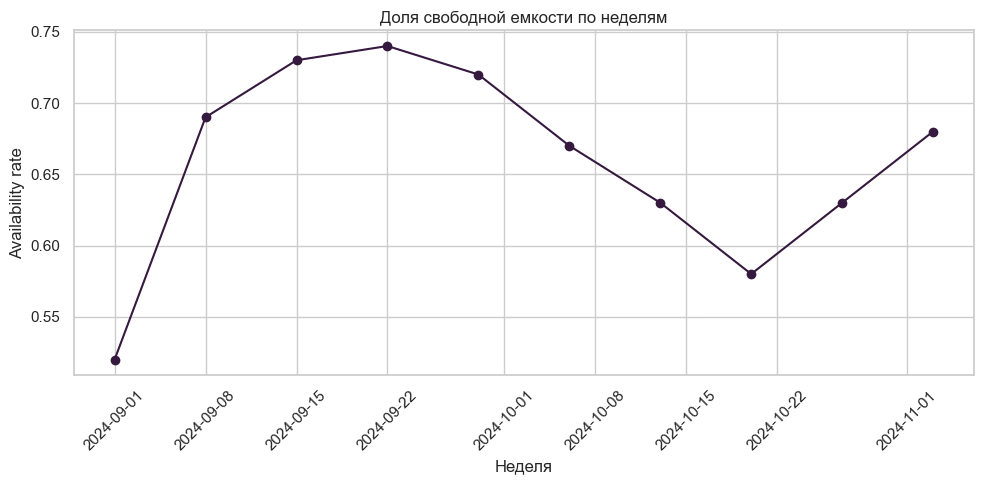

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekly_availability["interval_start_date"],
    weekly_availability["availability_rate"],
    marker="o"
)

plt.title("Доля свободной емкости по неделям")
plt.xlabel("Неделя")
plt.ylabel("Availability rate")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [47]:
timeline.head(3)

,interval_start_date,slots_cnt,total_capacity,total_consumed_capacity,total_free_capacity,availability_rate
0,2024-09-01,4148,11569.0,5599.0,5970.0,0.52
1,2024-09-02,4248,16505.0,5640.0,10865.0,0.66
2,2024-09-03,4106,19714.0,4998.0,14716.0,0.75


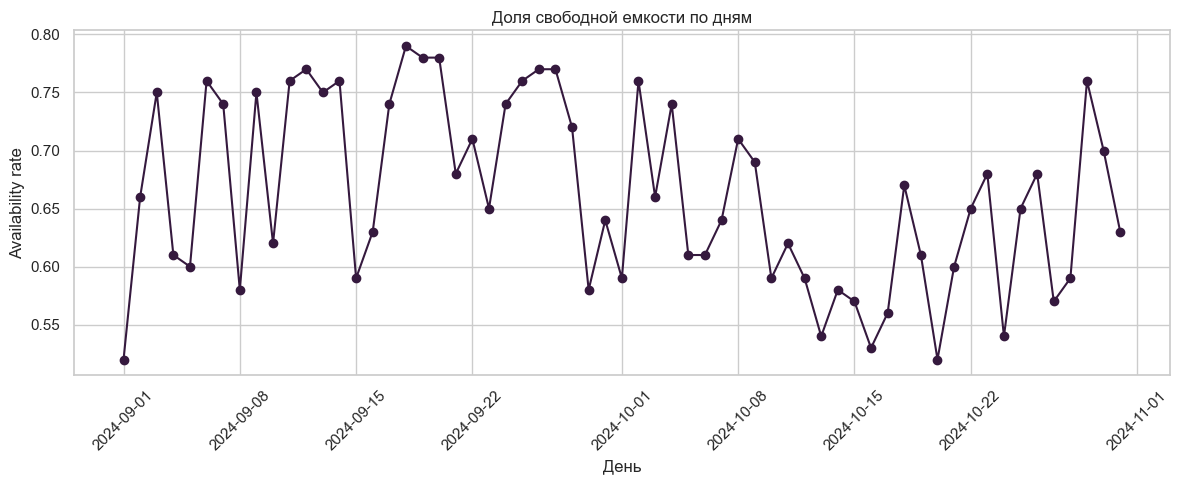

In [48]:
plt.figure(figsize=(12, 5))

plt.plot(
    timeline["interval_start_date"],
    timeline["availability_rate"],
    marker="o"
)

plt.title("Доля свободной емкости по дням")
plt.xlabel("День")
plt.ylabel("Availability rate")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
# а еще интересно посмотреть в зонах как шла заполняетмость слотов

zone_availability = (
    slot_level
    .groupby("src_zone_id", as_index=False)
    .agg(
        slots_cnt=("slot_id", "nunique"),
        total_capacity=("available_capacity_last", "sum"),
        total_consumed_capacity=("consumed_capacity", "sum"),
        total_free_capacity=("free_capacity", "sum")
    )
)

zone_availability["availability_rate"] = round(
    zone_availability["total_free_capacity"] / zone_availability["total_capacity"],
    2
)


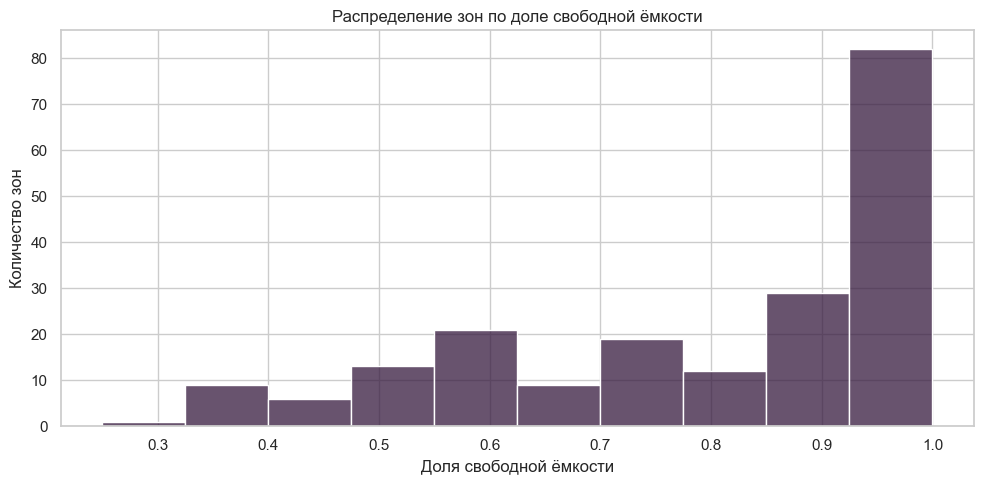

In [50]:
# посмотрю на распределение зон по доле свободной емкости
plt.figure(figsize=(10, 5))

sns.histplot(
    data=zone_availability,
    x="availability_rate",
    bins=10
)

plt.title("Распределение зон по доле свободной ёмкости")
plt.xlabel("Доля свободной ёмкости")
plt.ylabel("Количество зон")
plt.tight_layout()
plt.show()

## Вывод
В целом по анализируемому периоду доставка не выглядит перегруженной: значительная часть задекларированной емкости остаётся свободной. Это означает, что на агрегированном уровне у клиентов, скорее всего, сохранялся выбор доступных слотов.

При этом доступность распределена неравномерно. По недельной динамике видно, что в сентябре доля свободной емкости была выше, а в октябре наблюдалось снижение availability_rate. Также распределение по зонам показывает, что значительная часть зон имеет очень высокую долю незаполненной емкости. В этих зонах задекларированная capacity, вероятно, существенно превышает фактический спрос.

Важно отметить, что поток заказов по дням относительно стабилен, тогда как задекларированная ёмкость меняется заметно сильнее. Поэтому скачки availability_rate в большей степени объясняются изменениями планируемой capacity, а не резкими изменениями спроса.
С операционной точки зрения высокая незаполненная емкость может указывать на неэффективное планирование: часть capacity выделяется, но не используется. Возможно, имеет смысл выравнивать задекларированную ёмкость и держать её ближе к уровню ожидаемого спроса с учётом прогнозного целевого запаса.

Еще хочу отметить, что зоны с низкой долей свободной емкости стоит анализировать отдельно как риск дефицита слотов, а зоны с высокой долей свободной емкости — как риск избыточно выставленной емкости.


# 2. Cформулировать метрики, характеризующие доступность слотов доставки для клиентов и позволяющие идентифицировать проблемы с ёмкостью и доступностью слотов

Для оценки доступности слотов были рассчитаны метрики на уровне одного слота. 
В качестве финальной емкости использовалась `available_capacity_last`, фактическое потребление слота определялось как максимум `consumed_capacity_cum`. Свободная емкость рассчитывалась как разница между финальной емкостью и потреблением: `free_capacity` = `available_capacity_last` - `consumed_capacity`.

Для анализа доступности использовалась долевая метрика: `availability_rate` = `free_capacity` / `available_capacity_last`, показывающая долю свободной емкости.

К метрике `availability_rate` нужно добавить некие thresholds:
 - низкая заполняемость, например,  `availability_rate` >= 0.7
 - емкость выставлена и не заполнена,   `availability_rate` = 1
 - слот заполнен раньше планируемого
 - зона, в которой средняя свободная емкость низкая, то есть зоны с риском не удовлетворить спрос, напримерб `availability_rate` <= 0.25
 + слоты, в которых заказов больше, чем задекларированная емкость

# 3 Вывести детальную информацию по слотам, имеющим проблемы, в виде, понятном для операционного менеджера, ответственного за настройку слотов

    Что такое "проблемные слоты"?

    1. Дефицит емкости: спрос есть, а слоты почти выбраны
    2. Избыток емкости:  емкость задекларирована, но не заполняется заказами.

А еще есть такой момент: слоты могут иметь емкость как очень небольшую (1-2-3), так и до 150.
Надо как-то учесть эту проблему масштаба.
Для простоты, можно игнорировать слоты с емкостью меньше 10 заказов. Думаю, для таких заказов дефицит емкости решается проще, чем для слотов с емкостью на сотни заказов.

In [51]:
# добавлю rate-метрику на уровень слота
slot_level["availability_rate"]=round(slot_level["free_capacity"]/slot_level["available_capacity_last"],2)
slot_level.head(3)


,slot_id,interval_start_date,src_zone_id,service_level_code,level_1,level_2,interval_cutoff_dttm,interval_start_dttm,interval_end_dttm,available_capacity_first,available_capacity_last,capacity_delta,was_expanded,first_order_hour,last_order_hour,consumed_capacity_hourly_sum,consumed_capacity,free_capacity,availability_rate
0,20694,2024-09-22,1220839,exact60,LMD Moscow South,Moscow,2024-09-21 23:59:00,2024-09-22 18:00:00,2024-09-22 19:00:00,2.0,2.0,0.0,0,NaT,NaT,0.0,0.0,2.0,1.0
1,43529,2024-09-07,1354357,same_day60,LMD Moscow South,Moscow,2024-09-07 15:30:00,2024-09-07 23:00:00,2024-09-07 23:59:00,5.0,5.0,0.0,0,NaT,NaT,0.0,0.0,5.0,1.0
2,44642,2024-10-17,1263362,plus15,LMD Moscow South,Moscow,2024-10-16 23:59:00,2024-10-17 19:30:00,2024-10-17 19:45:00,2.0,2.0,0.0,0,NaT,NaT,0.0,0.0,2.0,1.0


## Слоты с дефицитом емкости

Пускай, это будут слоты с низким запасом свободной ёмкости: свободно осталось не больше 25% емкости.

In [52]:
# ищу слоты с дефицитом емкости
cap_deficit = slot_level[
    (slot_level["availability_rate"]<=0.25)&
    (slot_level["available_capacity_last"] >= 10)
    ]
cap_deficit.sort_values(["interval_start_date", "src_zone_id", "availability_rate"])
cap_deficit.to_csv("capacity_deficit_lower_than_0_25%.csv")
# ого, есть даже отрицательные availability_rate - тоже претендент на метрику контроля

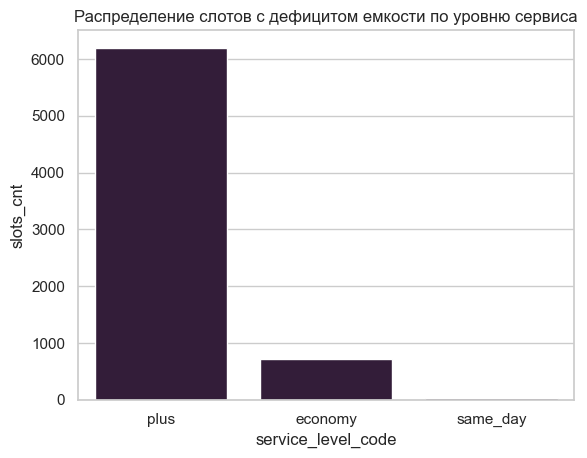

In [53]:
cap_deficit.groupby("service_level_code", as_index=False).agg(slots_cnt=("slot_id", 'count')).sort_values("slots_cnt", ascending=False)
# распределение слотов с дефицитом емкости по уровню сервиса

sns.barplot(
    data=cap_deficit.groupby("service_level_code", as_index=False).agg(slots_cnt=("slot_id", 'count')).sort_values("slots_cnt", ascending=False),
    x="service_level_code",
    y="slots_cnt")
plt.title("Распределение слотов с дефицитом емкости по уровню сервиса");

In [54]:
by_zone = cap_deficit.groupby("src_zone_id", as_index=False).agg(slots_cnt=("slot_id", 'count')).sort_values("slots_cnt", ascending=False)
# распределение слотов с дефицитом емкости по зонам доставки
by_zone.to_csv("slots_count_with_cap_deficit_by_zone.csv")

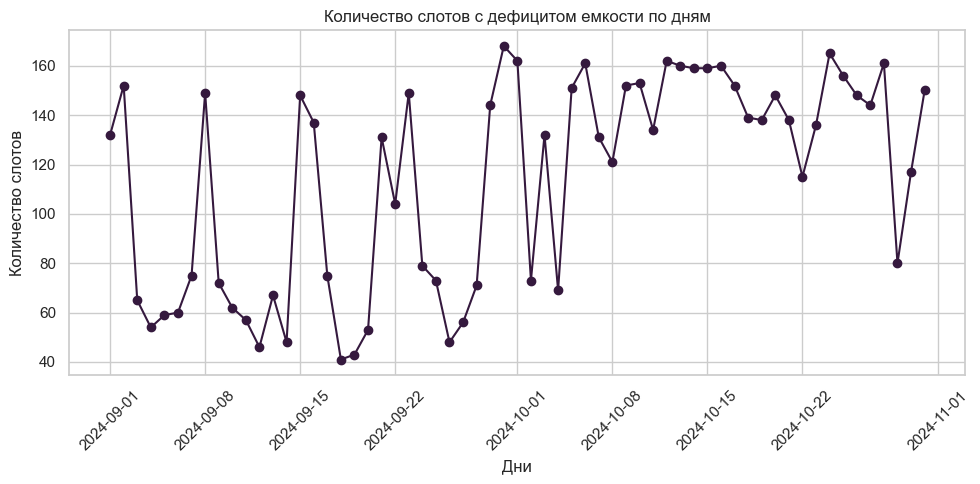

In [55]:
cap_deficit_by_days = cap_deficit.groupby("interval_start_date", as_index=False).agg(
    total_capacity=("available_capacity_last", "sum"),
    total_consumed_capacity=("consumed_capacity", "sum"),
    total_free_capacity=("free_capacity", "sum"),
    slot_cnt=("slot_id", "count"))
plt.figure(figsize=(10, 5))

plt.plot(
    cap_deficit_by_days["interval_start_date"],
    cap_deficit_by_days["slot_cnt"],
    marker="o"
)

plt.title("Количество слотов с дефицитом емкости по дням")
plt.xlabel("Дни")
plt.ylabel("Количество слотов")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
# заметна недельная цикличность

In [56]:
cap_deficit_by_days

,interval_start_date,total_capacity,total_consumed_capacity,total_free_capacity,slot_cnt
0,2024-09-01,3244.0,3538.0,-294.0,132
1,2024-09-02,3711.0,3937.0,-226.0,152
2,2024-09-03,1633.0,1526.0,107.0,65
3,2024-09-04,1414.0,1310.0,104.0,54
4,2024-09-05,1504.0,1429.0,75.0,59
...,...,...,...,...,...
56,2024-10-27,3734.0,3716.0,18.0,144
57,2024-10-28,4274.0,4311.0,-37.0,161
58,2024-10-29,1721.0,1674.0,47.0,80
59,2024-10-30,3144.0,2938.0,206.0,117


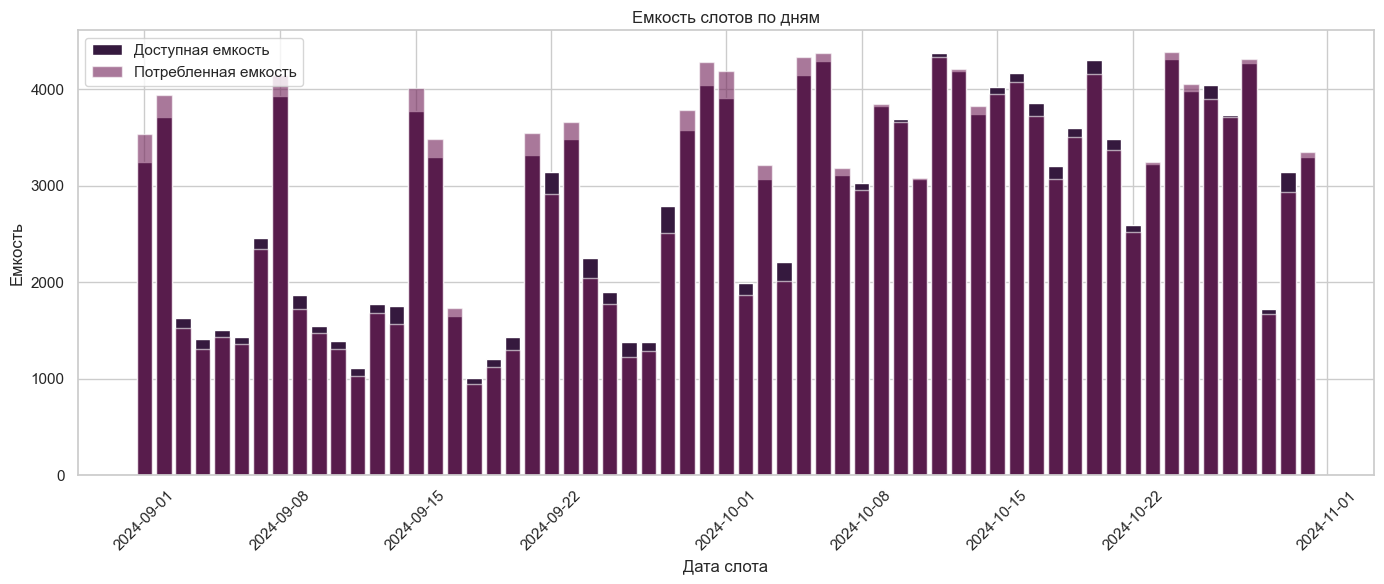

In [57]:
plt.figure(figsize=(14, 6))

plt.bar(
    cap_deficit_by_days["interval_start_date"],
    cap_deficit_by_days["total_capacity"],
    label="Доступная емкость"
)

plt.bar(
    cap_deficit_by_days["interval_start_date"],
    cap_deficit_by_days["total_consumed_capacity"],
    label="Потребленная емкость",
    alpha=0.6
)

plt.xticks(rotation=45)
plt.title("Емкость слотов по дням")
plt.xlabel("Дата слота")
plt.ylabel("Емкость")
plt.legend()
plt.tight_layout()
plt.show()

### Отчет для менеджеров

    Для анализа потенциальных проблем с доступностью доставки были рассмотрены слоты с низким запасом свободной емкости (`availability_rate <= 0.25`), то есть слоты, в которых оставалось не более 25% свободной емкости. При этом были отброшены слоты с допустимой емкостью меньше или равно 10, чтобы сгладить масштаб.
    
    Количество слотов с дефицитом емкости заметно увеличивается с конца сентября и достигает максимума в октябре. При этом потреблённая ёмкость в них практически совпадает с выставленной, что свидетельствует о высоком уровне заполнения, а где-то и превышает, что требует особого внимания.

    Наибольшее количество дефицитных слотов приходится на сервис `plus`, `economy` и `plus15`. Это указывает на повышенный риск нехватки емкости в наиболее востребованных интервалах доставки. Для снижения риска рекомендуется дополнительно проанализировать зоны и интервалы, где дефицит возникает регулярно, и при необходимости скорректировать емкость или перераспределить ресурсы между менее и более загруженными слотами.
    В приложении сохранены список всех слотов с дефицитом емкости меньше 25%, таблица отсортирована по дате, зоне и уровню доступности. В первую очередь менеджеру стоит смотреть строки с минимальным availability_rate, нулевой или отрицательной free_capacity, а также повторяющиеся зоны и сервисы.
    Также прилагается список зон с количеством слотов с дефицитом по ним.


## Слоты с избытком емкости
Возьмем критической границей 80% емкости

In [58]:
# ищу слоты с избыткома я емкости
cap_proficit = slot_level[
    (slot_level["availability_rate"]>=0.80)&
    (slot_level["available_capacity_last"] >= 10)
    ]
cap_proficit.sort_values(["interval_start_date", "src_zone_id", "availability_rate"])

,slot_id,interval_start_date,src_zone_id,service_level_code,level_1,level_2,interval_cutoff_dttm,interval_start_dttm,interval_end_dttm,available_capacity_first,available_capacity_last,capacity_delta,was_expanded,first_order_hour,last_order_hour,consumed_capacity_hourly_sum,consumed_capacity,free_capacity,availability_rate
64041,1080614074,2024-09-01,32,plus,LMD Moscow South,Moscow,2024-08-31 23:59:00,2024-09-01 20:00:00,2024-09-02 00:00:00,20.0,20.0,0.0,0,NaT,NaT,0.0,0.0,20.0,1.0
69245,1168840999,2024-09-01,34,plus,LMD Moscow South,Moscow,2024-08-31 23:59:00,2024-09-01 13:00:00,2024-09-01 17:00:00,10.0,10.0,0.0,0,NaT,NaT,0.0,0.0,10.0,1.0
119838,2011226987,2024-09-01,34,plus,LMD Moscow South,Moscow,2024-08-31 23:59:00,2024-09-01 17:00:00,2024-09-01 21:00:00,10.0,10.0,0.0,0,NaT,NaT,0.0,0.0,10.0,1.0
198288,3327840245,2024-09-01,34,plus,LMD Moscow South,Moscow,2024-08-31 23:59:00,2024-09-01 09:00:00,2024-09-01 13:00:00,10.0,10.0,0.0,0,NaT,NaT,0.0,0.0,10.0,1.0
33279,560346162,2024-09-01,358,same_day,LMD Moscow South,Moscow,2024-09-01 12:00:00,2024-09-01 18:00:00,2024-09-01 23:59:00,40.0,40.0,0.0,0,NaT,NaT,0.0,0.0,40.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134233,2252129895,2024-10-31,1583518,same_day60,LMD Moscow South,Moscow,2024-10-31 12:00:00,2024-10-31 22:00:00,2024-10-31 23:59:00,12.0,12.0,0.0,0,NaT,NaT,0.0,0.0,12.0,1.0
233727,3923911420,2024-10-31,1583518,same_day60,LMD Moscow South,Moscow,2024-10-31 12:00:00,2024-10-31 20:00:00,2024-10-31 22:00:00,12.0,12.0,0.0,0,NaT,NaT,0.0,0.0,12.0,1.0
246673,4139767446,2024-10-31,1583518,same_day60,LMD Moscow South,Moscow,2024-10-31 12:00:00,2024-10-31 18:00:00,2024-10-31 20:00:00,12.0,12.0,0.0,0,NaT,NaT,0.0,0.0,12.0,1.0
253436,4254236515,2024-10-31,1583518,same_day,LMD Moscow South,Moscow,2024-10-31 12:00:00,2024-10-31 20:00:00,2024-10-31 22:00:00,12.0,12.0,0.0,0,NaT,NaT,0.0,0.0,12.0,1.0


In [59]:
cap_proficit.shape

(13095, 19)

In [60]:
# из них есть слоты полностью пустые
slots_without_orders = cap_proficit[cap_proficit["first_order_hour"].isna()]
slots_without_orders.shape

(11113, 19)

In [61]:
slots_without_orders.to_csv("slots_without_orders.csv")

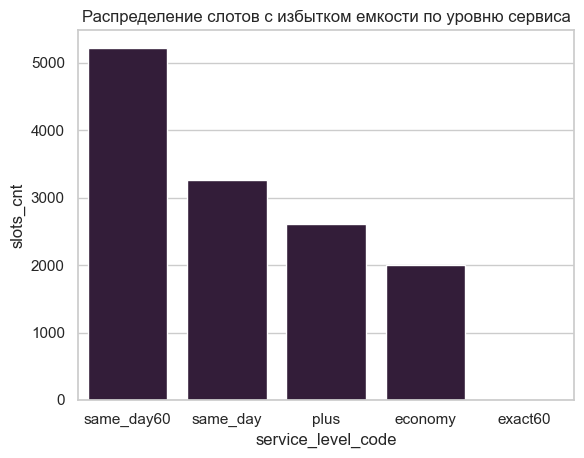

In [62]:
cap_proficit.groupby("service_level_code", as_index=False).agg(slots_cnt=("slot_id", 'count')).sort_values("slots_cnt", ascending=False)
# распределение слотов с избытком емкости по уровню сервиса

sns.barplot(
    data=cap_proficit.groupby("service_level_code", as_index=False).agg(slots_cnt=("slot_id", 'count')).sort_values("slots_cnt", ascending=False),
    x="service_level_code",
    y="slots_cnt")
plt.title("Распределение слотов с избытком емкости по уровню сервиса");

In [63]:
by_zone_proficit = cap_proficit.groupby("src_zone_id", as_index=False).agg(slots_cnt=("slot_id", 'count')).sort_values("slots_cnt", ascending=False)
# распределение слотов с bp,snrjv емкости по зонам доставки
by_zone_proficit

,src_zone_id,slots_cnt
12,2292,732
51,1263362,348
18,1101507,348
67,1512536,295
114,1583443,291
...,...,...
98,1569908,2
2,35,2
127,1603308,2
24,1169002,1


In [64]:
by_zone_proficit.to_csv("slots_count_with_cap_proficit_by_zone.csv")

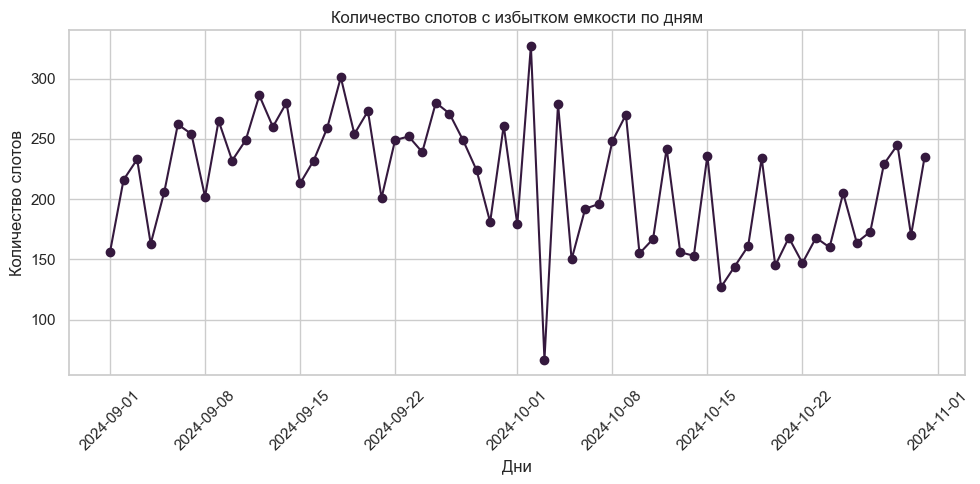

In [65]:
cap_proficit_by_days = cap_proficit.groupby("interval_start_date", as_index=False).agg(
    total_capacity=("available_capacity_last", "sum"),
    total_consumed_capacity=("consumed_capacity", "sum"),
    total_free_capacity=("free_capacity", "sum"),
    slot_cnt=("slot_id", "count"))
plt.figure(figsize=(10, 5))

plt.plot(
    cap_proficit_by_days["interval_start_date"],
    cap_proficit_by_days["slot_cnt"],
    marker="o"
)

plt.title("Количество слотов с избытком емкости по дням")
plt.xlabel("Дни")
plt.ylabel("Количество слотов")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [66]:
# интересный провал,  цикличности уже нет так, как в слотах с дефицитами, поизучаю
cap_proficit_by_days.sort_values("slot_cnt").head(5)

,interval_start_date,total_capacity,total_consumed_capacity,total_free_capacity,slot_cnt
32,2024-10-03,2142.0,11.0,2131.0,67
45,2024-10-16,2726.0,4.0,2722.0,127
46,2024-10-17,3246.0,5.0,3241.0,144
49,2024-10-20,3115.0,6.0,3109.0,145
51,2024-10-22,3286.0,9.0,3277.0,147


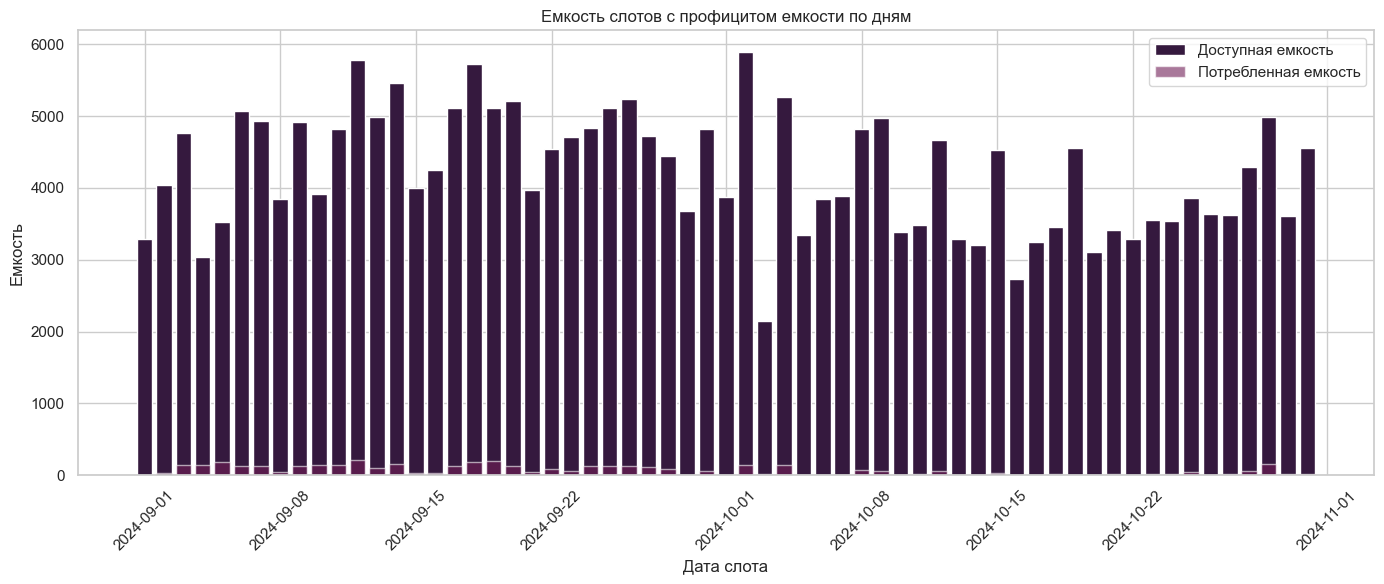

In [67]:
plt.figure(figsize=(14, 6))

plt.bar(
    cap_proficit_by_days["interval_start_date"],
    cap_proficit_by_days["total_capacity"],
    label="Доступная емкость"
)

plt.bar(
    cap_proficit_by_days["interval_start_date"],
    cap_proficit_by_days["total_consumed_capacity"],
    label="Потребленная емкость",
    alpha=0.6
)

plt.xticks(rotation=45)
plt.title("Емкость слотов с профицитом емкости по дням")
plt.xlabel("Дата слота")
plt.ylabel("Емкость")
plt.legend()
plt.tight_layout()
plt.show()

### Отчет для менеджеров
    Анализ слотов с избытком ёмкости

    Слоты с избытком ёмкости — это слоты, где значительная часть capacity осталась свободной. Для клиента это не проблема доступности, но для операционного планирования это сигнал возможного недоиспользования ресурсов.

    В сегмент попало около 13 тыс. слотов, при этом более 11 тыс. из них вообще не имели заказов. Это указывает на зоны, сервисы или интервалы, где ёмкость была выставлена, но фактического спроса не было.

    Чаще всего избыток ёмкости встречается в сервисах same_day60, same_day, plus и economy. По дням количество таких слотов нестабильно, с заметным провалом в начале октября.
    Рекомендация: проверить зоны и сервисы, где профицитные слоты повторяются регулярно, особенно случаи без заказов. Если паттерн устойчивый, capacity можно сократить или перераспределить в более загруженные зоны.